In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Bank Customer Churn Prediction.csv to Bank Customer Churn Prediction.csv


In [ ]:

!pip install supabase pandas -q

import pandas as pd
from supabase import create_client

# ⚠️ Credentials removed for security
# To run this notebook:
# 1. Create a free Supabase account at supabase.com
# 2. Create a project and get your URL + anon key
# 3. Replace the placeholders above with your credentials
SUPABASE_URL = "your-supabase-url-here"
SUPABASE_KEY = "your-anon-key-here"

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# Load CSV
df = pd.read_csv("Bank Customer Churn Prediction.csv")


df.columns = df.columns.str.lower().str.replace(" ", "_")


cols_to_select = ['customer_id','credit_score','country','gender',
                  'age','tenure','balance','products_number','credit_card',
                  'active_member','estimated_salary','churn']
df = df[cols_to_select]


df.columns = ['customer_id','credit_score','geography','gender',
              'age','tenure','balance','num_products','has_cr_card',
              'is_active_member','estimated_salary','exited']


for i in range(0, len(df), 500):
    batch = df[i:i+500].to_dict(orient='records')

    supabase.table("customers").upsert(batch, on_conflict='customer_id').execute()
    print(f"Uploaded rows {i} to {i+500}")

print("Done!")

Uploaded rows 0 to 500
Uploaded rows 500 to 1000
Uploaded rows 1000 to 1500
Uploaded rows 1500 to 2000
Uploaded rows 2000 to 2500
Uploaded rows 2500 to 3000
Uploaded rows 3000 to 3500
Uploaded rows 3500 to 4000
Uploaded rows 4000 to 4500
Uploaded rows 4500 to 5000
Uploaded rows 5000 to 5500
Uploaded rows 5500 to 6000
Uploaded rows 6000 to 6500
Uploaded rows 6500 to 7000
Uploaded rows 7000 to 7500
Uploaded rows 7500 to 8000
Uploaded rows 8000 to 8500
Uploaded rows 8500 to 9000
Uploaded rows 9000 to 9500
Uploaded rows 9500 to 10000
Done!


/tmp/ipykernel_1553/3774810576.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_age = df.groupby('age_band')['exited'].mean() * 100
/tmp/ipykernel_1553/3774810576.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_age.index, y=churn_age.values, palette='Reds_r')


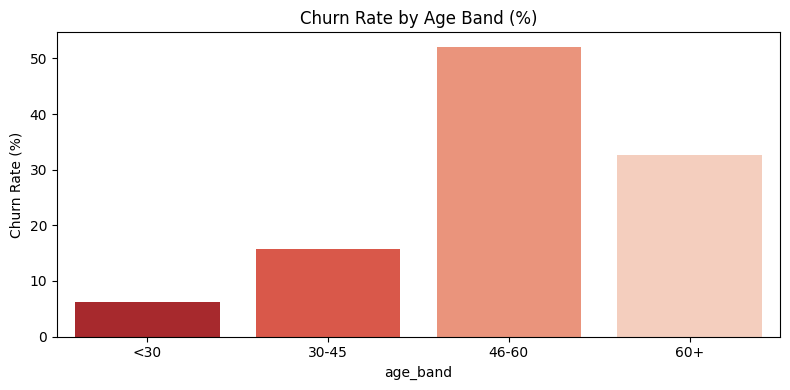

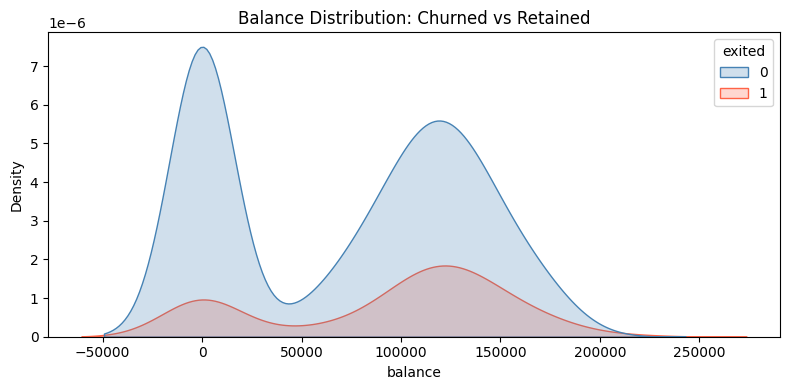

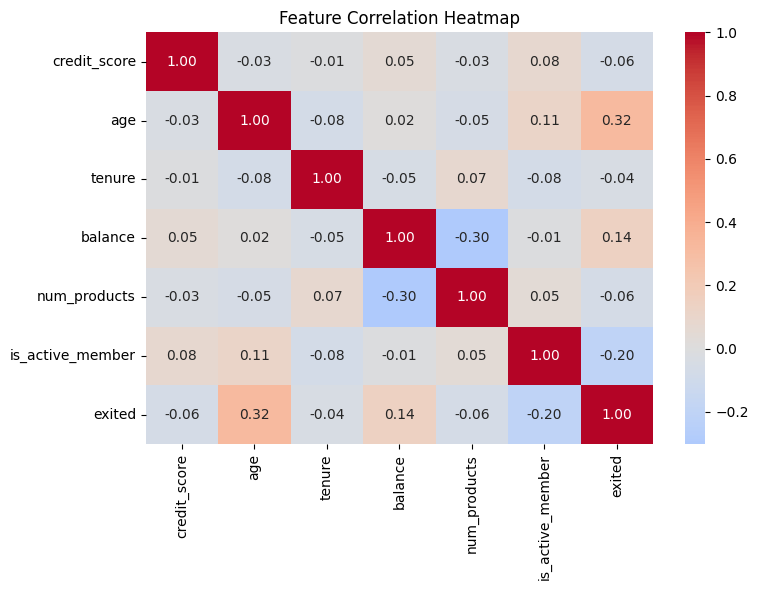

Total customers: 1,000
Churned: 207 (20.7%)
Revenue at risk: $19,449,207


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


response = supabase.table("customers").select("*").execute()
df = pd.DataFrame(response.data)

# --- Chart 1: Churn rate by age band ---
df['age_band'] = pd.cut(df['age'], bins=[0,30,45,60,100],
                        labels=['<30','30-45','46-60','60+'])
churn_age = df.groupby('age_band')['exited'].mean() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=churn_age.index, y=churn_age.values, palette='Reds_r')
plt.title('Churn Rate by Age Band (%)')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('churn_by_age.png', dpi=150)
plt.show()

# --- Chart 2: Balance distribution - churned vs retained ---
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='balance', hue='exited', fill=True,
            palette={0:'steelblue', 1:'tomato'})
plt.title('Balance Distribution: Churned vs Retained')
plt.tight_layout()
plt.savefig('balance_distribution.png', dpi=150)
plt.show()

# --- Chart 3: Correlation heatmap ---
plt.figure(figsize=(8, 6))
corr = df[['credit_score','age','tenure','balance',
           'num_products','is_active_member','exited']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


total = len(df)
churned = df['exited'].sum()
churn_rate = df['exited'].mean() * 100
revenue_at_risk = df[df['exited']==1]['balance'].sum()

print(f"Total customers: {total:,}")
print(f"Churned: {churned:,} ({churn_rate:.1f}%)")
print(f"Revenue at risk: ${revenue_at_risk:,.0f}")